In [1]:
!pip install -q langgraph langchain-openai langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.1/489.1 kB 14.7 MB/s eta 0:00:00


In [2]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage
import operator

In [4]:
class AgentState(TypedDict):
    messages:Annotated[list, operator.add]
    user_input:str
    processing_step:str
    result:str

print(" state schema defined")
print(f"-messages: accumalates conversation history")
print(f"-user_input: stores the original query")
print(f"-processing step: tracks workflow progress")
print(f"-result:stores the final output\n")

 state schema defined
-messages: accumalates conversation history
-user_input: stores the original query
-processing step: tracks workflow progress
-result:stores the final output



In [7]:
###define node function

In [9]:
def input_node(state:AgentState) ->AgentState:
    print(f"Input node: Recieved '{state['user_input']}'")
    return{
        "messages":[HumanMessage(content=state["user_input"])],
        "processing_step":"input_recieved"
    }
def analyze_node(state:AgentState) ->AgentState:
  print(f"analyze node: Analyzing input...")
  user_text= state["user_input"].lower()

  #simple analysis logic

  if "weather" is user_text:
    analysis = "weather-related query"
  elif "hello" in user_text or "hi" in user_text:
    analysis = "Greeting detected"
  else:
    analysis = "General query detected"

  return { "messages" : [AIMessage (content=f"Analysis:{analysis}")],
            "processing_step" : "analyzed"
  }

def process_node(state:AgentState) ->AgentState:
    print(f" process node : processing")
    user_text = state["user_input"].lower()

   # Generate a response based on the input
    if "weather" is user_text:
      response = "I would check the whether API for current conditions"
    elif "hello" in user_text or "hi" in user_text:
      response = "Hello! How can I help you today"
    else:
       response = f"I recieved your message : '{state['user_input']}'"
    return {
        "messages":[AIMessage(content=response)],
        "processingstep":"processed",
        "result":response
    }

def output_node(state:AgentState) ->AgentState:
  print(f"output node: Finalizing response...")

  final_message = f"Final Reponse: {state['result']}"

  return {
        "messages":[AIMessage(content=final_message)],
        "processingstep":"processed",
    }





<>:13: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:29: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:13: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:29: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipython-input-815998292.py:13: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if "weather" is user_text:
/tmp/ipython-input-815998292.py:29: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if "weather" is user_text:


In [11]:
## Build the graph

workflow = StateGraph(AgentState)

workflow.add_node("input", input_node)
workflow.add_node("analyze", analyze_node)
workflow.add_node("process", process_node)
workflow.add_node("output", output_node)

print("nodes added to graph")

nodes added to graph


In [12]:
## Define the workflow(edges)

workflow.set_entry_point("input")

## add edges to define the flow

workflow.add_edge("input","analyze")
workflow.add_edge("analyze","process")
workflow.add_edge("process","output")
workflow.add_edge("output",END)

In [13]:
app = workflow.compile()

In [18]:
def run_workflow(user_input:str):

    ## initial state

    initial_state = {
        "messages":[],
        "user_input": user_input,
        "processing_step":"initialized",
        "result":""
    }

    #Run the workflow

    final_state = app.invoke(initial_state)

    print(f" - processing step: {final_state['processing_step']}")
    print(f" - Result:{final_state['result']}")
    print(f" - Result:{len(final_state['messages'])}")

    return final_state


In [19]:
run_workflow("Hello!")

Input node: Recieved 'Hello!'
analyze node: Analyzing input...
 process node : processing
output node: Finalizing response...
 - processing step: analyzed
 - Result:Hello! How can I help you today
 - Result:4


{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Analysis:Greeting detected', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Hello! How can I help you today', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Final Reponse: Hello! How can I help you today', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'user_input': 'Hello!',
 'processing_step': 'analyzed',
 'result': 'Hello! How can I help you today'}

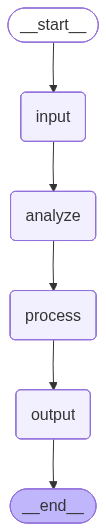

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))